# Linear Regression Analysis in Python

This notebook demonstrates a simple linear regression analysis using Python to model Salary based on YearsExperience.

## Objective

The goal of this analysis is to quantify the relationship between years of professional experience and annual salary. We will:

1. Explore the dataset structure and summary statistics
2. Visualize the relationship with a scatter plot
3. Fit a simple linear regression model using scikit-learn
4. Evaluate model performance with R² and mean squared error (MSE)
5. Interpret the fitted coefficients in the context of salary prediction

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

## Load Dataset

We read `regression_data.csv`, which contains paired observations of experience and salary.

In [2]:
DATA_FILE = "regression_data.csv"

df = pd.read_csv(DATA_FILE)
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## Inspect Dataset

We examine column names, data types, and non-null counts to confirm the dataset is ready for modeling.

In [3]:
print(f"Number of observations: {len(df)}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn data types:")
print(df.dtypes)
print("\nDataset info:")
df.info()

Number of observations: 10
Number of columns: 2

Column data types:
YearsExperience    float64
Salary             float64
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  10 non-null     float64
 1   Salary           10 non-null     float64
dtypes: float64(2)
memory usage: 288.0 bytes


## Summary Statistics

Descriptive statistics help characterize the central tendency and spread of both variables.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsExperience,10.0,2.49,1.018114,1.1,1.625,2.55,3.15,4.0
Salary,10.0,49833.90,9519.789814,37731.0,40799.500,50325.00,57052.25,63218.0


## Scatter Plot Visualization

A scatter plot provides an initial visual assessment of the linear trend between experience and salary.

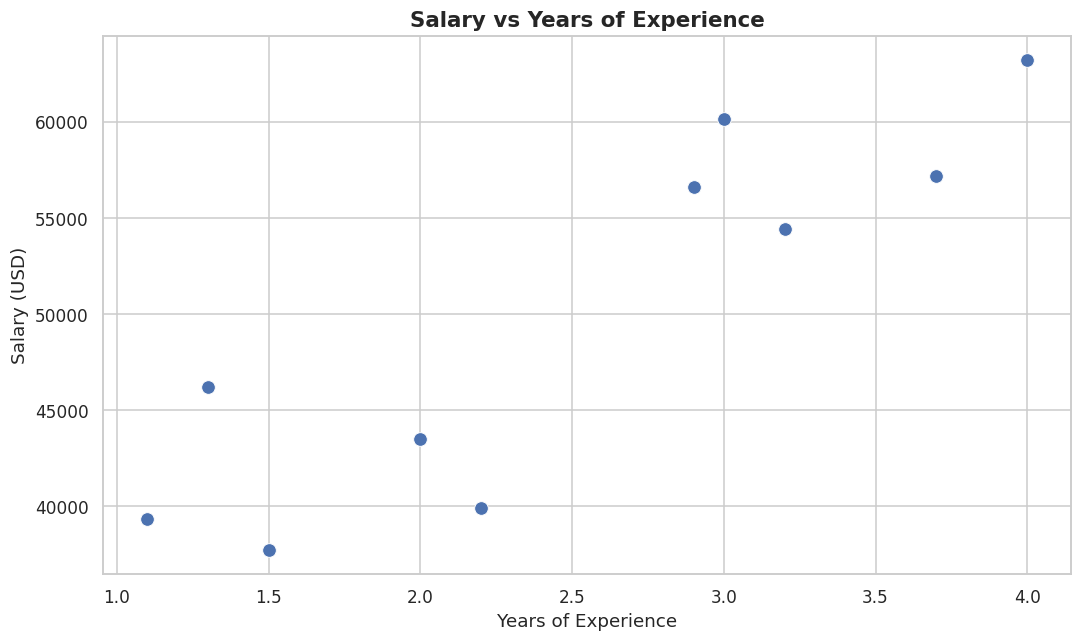

In [5]:
X_COLUMN = "YearsExperience"
Y_COLUMN = "Salary"

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x=X_COLUMN, y=Y_COLUMN, ax=ax, s=80, edgecolor="white", linewidth=0.6)
ax.set_title("Salary vs Years of Experience", fontsize=14, fontweight="bold")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary (USD)")
plt.tight_layout()
plt.show()

## Linear Regression Model

We fit a simple linear regression model of the form:

$$\text{Salary} = \beta_0 + \beta_1 \times \text{YearsExperience}$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope coefficient.

In [6]:
X = df[[X_COLUMN]].values
y = df[Y_COLUMN].values

model = LinearRegression()
model.fit(X, y)

coefficient = model.coef_[0]
intercept = model.intercept_
predictions = model.predict(X)

print(f"Coefficient (slope): {coefficient:.2f}")
print(f"Intercept:           {intercept:.2f}")

Coefficient (slope): 8285.29
Intercept:           29203.52


## Regression-Line Visualization

Overlaying the fitted regression line on the scatter plot helps visualize how well the linear model captures the trend.

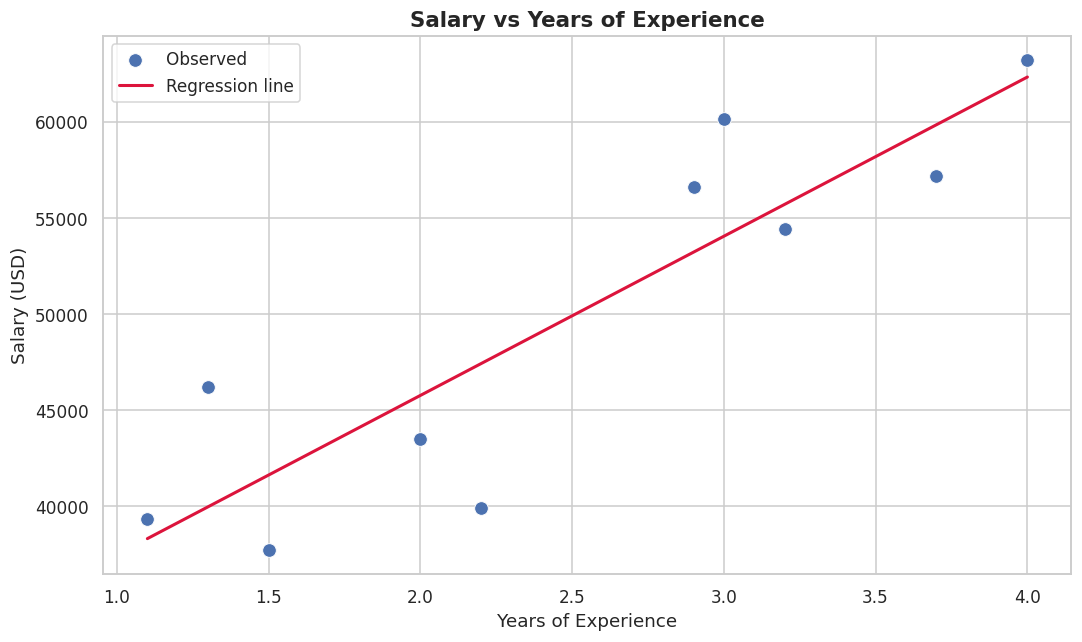

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x=X_COLUMN, y=Y_COLUMN, ax=ax, s=80, edgecolor="white", linewidth=0.6, label="Observed")

x_line = np.linspace(df[X_COLUMN].min(), df[X_COLUMN].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
ax.plot(x_line.ravel(), y_line, color="crimson", linewidth=2.0, label="Regression line")

ax.set_title("Salary vs Years of Experience", fontsize=14, fontweight="bold")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Model Evaluation

We assess predictive performance using R² (proportion of variance explained) and MSE (average squared prediction error).

In [8]:
r_squared = r2_score(y, predictions)
mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)

print(f"R-squared: {r_squared:.4f}")
print(f"MSE:       {mse:,.2f}")
print(f"RMSE:      {rmse:,.2f}")

R-squared: 0.7852
MSE:       17,523,844.08
RMSE:      4,186.15


## Interpretation of Results

The fitted slope coefficient estimates the average change in salary (USD) associated with one additional year of experience. The intercept represents the predicted salary when years of experience equals zero; while not always meaningful in practice, it anchors the regression line.

R² indicates how much of the variability in salary is explained by years of experience. Values closer to 1.0 suggest a stronger linear relationship. MSE summarizes the magnitude of prediction errors in squared salary units; RMSE expresses this error on the original salary scale and is often easier to interpret.

For this dataset, the positive slope and high R² suggest that salary increases systematically with experience, supporting the use of a simple linear model for exploratory prediction.

## Conclusion

This notebook implemented a complete linear regression workflow in Python: data loading, exploratory analysis, model fitting, visualization, and evaluation. The results demonstrate a clear positive association between years of experience and salary.

Future extensions could include confidence intervals for coefficients, residual diagnostics, or regularized models if additional predictors are introduced.